# Retail Sales EDA
## Project Overview.
Analysis of Superstore retail sales data (obtained from [Kaggle](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final)) to understand revenue performance,
product category trends, regional distribution, and the impact of discounts on profitability.

## Project Business Questions.
1. What does the data look like?
2. What is the overall sales and profit performance?
3. Which product categories and sub-categories drive the most revenue and profit?
4. How do sales vary across regions?
5. Is there a relationship between discount and profit?
6. How have sales trended over time?

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All packages imported successfully")
# print(f"pandas version: {pd.__version__}")

All packages imported successfully


## Initial data inspection.

In [4]:
# load Superstore dataset
# data not encoded in UTF-8, so latin-1 encoding is used
ss_df = pd.read_csv('../data/superstore.csv', encoding='latin-1')
print('Dataset loaded successfully')

# check the shape of the dataset
print(f'Dataset shape: {ss_df.shape}')

Dataset loaded successfully
Dataset shape: (9994, 21)


In [5]:
# show the first few rows of the dataset
ss_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
#check column names and data types
ss_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [7]:
# check for missing values
print(f'Missing values in each column:\n{ss_df.isna().sum()}')

Missing values in each column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


## Overall sales and profit performance.

In [8]:
# total sales across all orders
total_sales = ss_df['Sales'].sum()
print(f'Total sales across all orders: ${total_sales:,.2f}\n')

# total profit across all orders
total_profit = ss_df['Profit'].sum()
print(f'Total profit across all orders: ${total_profit:,.2f}\n')

# average order sale value
avg_sale_order = ss_df['Sales'].mean()
print(f'Average order sale value: ${avg_sale_order:,.2f}\n')

# average profit per order
avg_profit_order = ss_df['Profit'].mean()
print(f'Average profit per order: ${avg_profit_order:,.2f}\n')

# overall profit margin 
profit_margin = (total_profit / total_sales) * 100
print(f'Overall profit margin: {profit_margin:.2f}%')

Total sales across all orders: $2,297,200.86

Total profit across all orders: $286,397.02

Average order sale value: $229.86

Average profit per order: $28.66

Overall profit margin: 12.47%


## Interpretation
The superstore recorded a total sale amount of $2,297,200.86 across all orders. The total profit amounted to $286,397.02 demonstrating a 12.47\% profit margin which is above the retail industry average (~3-10\%) suggesting that the company is making good pricing decisions. However, the average sale on an order is $229.86 with an average profit of $28.66 which suggests that the average transaction is on a moderate scale. We can investigate further to uncover what accounts for this profit per order amount.

## Which product categories and sub-categories drive the most revenue and profit

In [9]:
# sort the dataset by profit in descending order
revenue_by_category = ss_df.groupby(['Category', 'Sub-Category'])[['Sales', 'Profit']].sum()

sorted_revenue_by_category = revenue_by_category.sort_values(by='Profit', ascending=False)
sorted_revenue_by_category

Sales      Profit
Category        Sub-Category                         
Technology      Copiers       149528.0300  55617.8249
                Phones        330007.0540  44515.7306
                Accessories   167380.3180  41936.6357
Office Supplies Paper          78479.2060  34053.5693
                Binders       203412.7330  30221.7633
Furniture       Chairs        328449.1030  26590.1663
Office Supplies Storage       223843.6080  21278.8264
                Appliances    107532.1610  18138.0054
Furniture       Furnishings    91705.1640  13059.1436
Office Supplies Envelopes      16476.4020   6964.1767
                Art            27118.7920   6527.7870
                Labels         12486.3120   5546.2540
Technology      Machines      189238.6310   3384.7569
Office Supplies Fasteners       3024.2800    949.5182
                Supplies       46673.5380  -1189.0995
Furniture       Bookcases     114879.9963  -3472.5560
                Tables        206965.5320 -17725.4811

In [10]:
sorted_revenue_by_category_reset = sorted_revenue_by_category.reset_index().set_index('Sub-Category')
sorted_revenue_by_category_reset

,Category,Sales,Profit
Sub-Category,,,
Copiers,Technology,149528.0300,55617.8249
Phones,Technology,330007.0540,44515.7306
Accessories,Technology,167380.3180,41936.6357
Paper,Office Supplies,78479.2060,34053.5693
Binders,Office Supplies,203412.7330,30221.7633
Chairs,Furniture,328449.1030,26590.1663
Storage,Office Supplies,223843.6080,21278.8264
Appliances,Office Supplies,107532.1610,18138.0054
Furnishings,Furniture,91705.1640,13059.1436


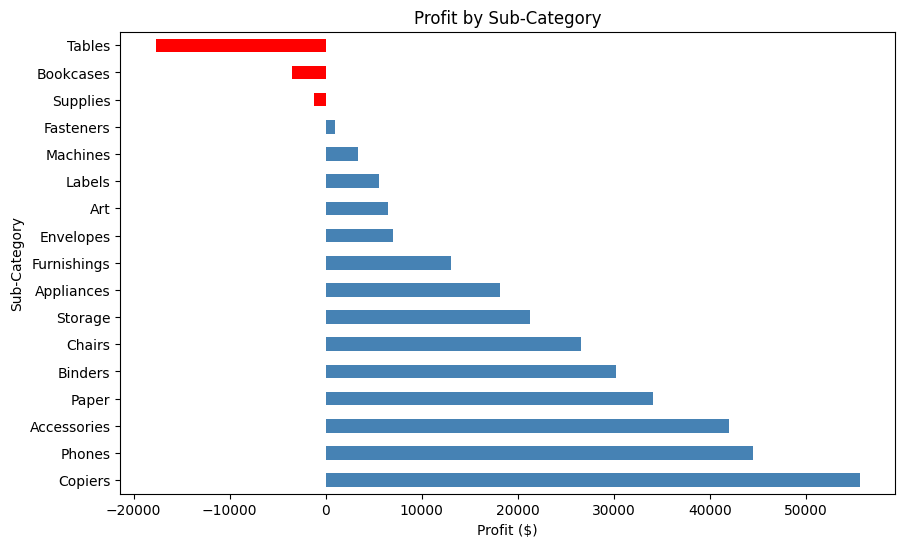

In [20]:
colorlist = ['steelblue' if profit >= 0 else 'red' for profit in sorted_revenue_by_category_reset['Profit']]
sorted_revenue_by_category_reset.plot(kind='barh', y = 'Profit', figsize = (10,6), legend = False, color = colorlist,
                                      title = 'Profit by Sub-Category',  xlabel = 'Profit ($)', ylabel = 'Sub-Category')
# plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.savefig('../reports/profit_by_subcategory.png', bbox_inches='tight', dpi=150)

### Interpretation
The analysis shows that the Technology category is the top profit driver, led by Copiers (~$56K), Phones (~$45K), and Accessories (~$42K).Tables is the least profitable sub-category with ~$17K in losses despite high sales records, suggesting possible pricing or cost management issues. The Office Supplies category is driven by Paper (~$34K) and Binders (~$30K). Furniture is driven by Chairs (~$27K) but has the least profitable sub-categories, also despite reasonably high sales volume. This suggests that the company may stand to make more profit by reevaluating pricing and cost management strategies regarding these categories.